# Etapa 7 — Avaliação Cruzada · Stage 4 (FinBERT, 4–5 anos)

Este notebook reavalia os 4 modelos do projeto (BiLSTM original, BiLSTM reduzido, XGBoost, Transformer) sobre o dataset **1.227 dias × 16 features (11 preço + 5 sentimento FinBERT-PT-BR)**, usando os utilitários compartilhados em `shared/` para garantir comparabilidade entre etapas.

## Protocolo

- Split walk-forward 70/15/15 (sem leakage temporal).
- Mesma normalização e mesmo target binário (sobe/desce).
- Métricas reportadas: **ROC-AUC** (primária), F1 por classe, accuracy, matriz de confusão.
- Resultados salvos em `results/` para consolidação cross-stage.

## Hipótese desta configuração

Features compactas e específicas do domínio financeiro superam embeddings genéricos. *Resultado esperado: Transformer atinge AUC ≈ 0.709 — melhor configuração do projeto.*

Ver `README.md` desta pasta e `BALANCEAMENTO_DE_CLASSES.md` para discussão de métricas em datasets desbalanceados.

In [1]:
import sys
import os
import logging

sys.path.insert(0, '.')

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")

from shared.data_loader import load_stage4_finbert_4y
from shared.trainer import train_and_evaluate, save_results_json
from shared.plots import (
    plot_roc_curves,
    plot_confusion_matrices,
    plot_calibration_diagrams,
    plot_temporal_stability,
    plot_prediction_distributions,
    plot_learning_curves,
    plot_feature_importance,
    plot_shap_summary,
)

print("Modulos carregados com sucesso")

18:53:55 [INFO] Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
18:53:55 [INFO] NumExpr defaulting to 16 threads.


Modulos carregados com sucesso


# Stage 4: FinBERT Sentiment (4 anos) — Avaliacao Completa

Retreino dos 7 modelos com features de sentimento FinBERT-PT-BR + preco.
Dataset: ~1227 dias, 16 features (11 preco + 5 sentimento), horizonte 21 dias.

In [2]:
data = load_stage4_finbert_4y(horizon=21, window=30)
print(f"Descricao: {data['description']}")
print(f"Sequencias: {data['X_seq'].shape}")
print(f"Tabular: {data['X_flat'].shape}")
print(f"Features: {data['feature_names']}")
print(f"Balance: {data['y_seq'].mean():.1%} sobe / {1-data['y_seq'].mean():.1%} desce")

Descricao: Stage 4: FinBERT sentiment + preco (4 anos)
Sequencias: (2717, 30, 16)
Tabular: (2747, 16)
Features: ['Close', 'Volume', 'return', 'ma7', 'ma21', 'std21', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'n_articles', 'mean_logit_pos', 'mean_logit_neg', 'mean_logit_neu', 'mean_sentiment']
Balance: 56.7% sobe / 43.3% desce


## Treino dos 7 modelos (configuracao padrao)

In [3]:
MODEL_CONFIGS = {
    "BiLSTM Original": {"model_name": "bilstm_original"},
    "BiLSTM Reduzido": {"model_name": "bilstm_reduced"},
    "Transformer": {"model_name": "transformer"},
    "TCN": {"model_name": "tcn"},
    "XGBoost": {"model_name": "xgboost"},
    "Logistic Regression": {"model_name": "logistic_regression"},
    "Random Forest": {"model_name": "random_forest"},
}

results = {}
for display_name, config in MODEL_CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"Treinando: {display_name}")
    print(f"\n{'='*60}")
    results[display_name] = train_and_evaluate(
        model_name=config["model_name"],
        data=data,
        compute_shap=True,
        compute_learning_curve=True,
    )

18:53:58 [INFO] 
18:53:58 [INFO] Modelo: bilstm_original
18:53:58 [INFO] Split — treino: 1901 | val: 407 | teste: 409
18:53:58 [INFO] ============================================================



Treinando: BiLSTM Original



18:53:59 [INFO] Class weights: sobe=0.856, desce=1.168 (balance: 53.9% sobe)
18:54:00 [INFO] Epoch   1/50 | loss 0.6872 | val_loss 0.8480 | val_acc 36.9% | lr 1.00e-03
18:54:00 [INFO] Epoch   2/50 | loss 0.7040 | val_loss 0.7459 | val_acc 36.9% | lr 1.00e-03
18:54:01 [INFO] Epoch   3/50 | loss 0.6739 | val_loss 0.7598 | val_acc 36.9% | lr 1.00e-03
18:54:01 [INFO] Epoch   4/50 | loss 0.6749 | val_loss 0.7300 | val_acc 36.9% | lr 1.00e-03
18:54:01 [INFO] Epoch   5/50 | loss 0.6640 | val_loss 0.8152 | val_acc 36.9% | lr 1.00e-03
18:54:02 [INFO] Epoch   6/50 | loss 0.6501 | val_loss 0.8236 | val_acc 36.9% | lr 1.00e-03
18:54:02 [INFO] Epoch   7/50 | loss 0.6403 | val_loss 0.9446 | val_acc 36.9% | lr 1.00e-03
18:54:02 [INFO] Epoch   8/50 | loss 0.6536 | val_loss 1.0258 | val_acc 36.9% | lr 1.00e-03
18:54:03 [INFO] Epoch   9/50 | loss 0.6740 | val_loss 0.6722 | val_acc 49.9% | lr 1.00e-03
18:54:03 [INFO] Epoch  10/50 | loss 0.6545 | val_loss 0.7200 | val_acc 37.1% | lr 1.00e-03
18:54:03 [INF


Treinando: BiLSTM Reduzido



18:54:06 [INFO] Epoch   1/50 | loss 0.6867 | val_loss 0.7212 | val_acc 36.9% | lr 1.00e-03
18:54:06 [INFO] Epoch   2/50 | loss 0.6733 | val_loss 0.7808 | val_acc 36.9% | lr 1.00e-03
18:54:06 [INFO] Epoch   3/50 | loss 0.6623 | val_loss 0.8176 | val_acc 37.1% | lr 1.00e-03
18:54:06 [INFO] Epoch   4/50 | loss 0.6512 | val_loss 0.9908 | val_acc 36.9% | lr 1.00e-03
18:54:07 [INFO] Epoch   5/50 | loss 0.6372 | val_loss 1.1045 | val_acc 37.6% | lr 1.00e-03
18:54:07 [INFO] Epoch   6/50 | loss 0.6224 | val_loss 1.0321 | val_acc 37.6% | lr 1.00e-03
18:54:07 [INFO] Epoch   7/50 | loss 0.6332 | val_loss 1.1216 | val_acc 39.6% | lr 5.00e-04
18:54:07 [INFO] Epoch   8/50 | loss 0.6151 | val_loss 1.1703 | val_acc 39.8% | lr 5.00e-04
18:54:07 [INFO] Epoch   9/50 | loss 0.6062 | val_loss 1.0986 | val_acc 41.3% | lr 5.00e-04
18:54:07 [INFO] Epoch  10/50 | loss 0.5931 | val_loss 1.0815 | val_acc 43.0% | lr 5.00e-04
18:54:08 [INFO] Epoch  11/50 | loss 0.5850 | val_loss 1.1914 | val_acc 42.5% | lr 5.00e-04

...

18:54:12 [INFO] Epoch   1/50 | loss 0.6835 | val_loss 0.8545 | val_acc 36.9% | lr 1.00e-03
18:54:13 [INFO] Epoch   2/50 | loss 0.6781 | val_loss 0.8222 | val_acc 36.9% | lr 1.00e-03
18:54:13 [INFO] Epoch   3/50 | loss 0.6551 | val_loss 0.9394 | val_acc 36.9% | lr 1.00e-03
18:54:13 [INFO] Epoch   4/50 | loss 0.6489 | val_loss 1.0640 | val_acc 36.9% | lr 1.00e-03
18:54:14 [INFO] Epoch   5/50 | loss 0.6376 | val_loss 1.2581 | val_acc 36.9% | lr 1.00e-03
18:54:14 [INFO] Epoch   6/50 | loss 0.6318 | val_loss 1.2002 | val_acc 36.9% | lr 1.00e-03
18:54:14 [INFO] Epoch   7/50 | loss 0.6317 | val_loss 1.6433 | val_acc 36.9% | lr 1.00e-03
18:54:15 [INFO] Epoch   8/50 | loss 0.6238 | val_loss 1.3683 | val_acc 36.9% | lr 5.00e-04
18:54:15 [INFO] Epoch   9/50 | loss 0.6100 | val_loss 1.5757 | val_acc 36.9% | lr 5.00e-04
18:54:15 [INFO] Epoch  10/50 | loss 0.6040 | val_loss 1.6958 | val_acc 36.9% | lr 5.00e-04
18:54:16 [INFO] Epoch  11/50 | loss 0.5958 | val_loss 1.8512 | val_acc 36.9% | lr 5.00e-04


Treinando: XGBoost



/home/takeo/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:54:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:54:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [18:54:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/h


Treinando: Logistic Regression


Treinando: Random Forest



18:54:17 [INFO] AUC: 0.5587 | Acc: 36.6% | F1: 0.0150 | ECE: 0.3875 | Brier: 0.3836
18:54:17 [INFO]               precision    recall  f1-score   support

       Desce       0.36      1.00      0.53       149
        Sobe       1.00      0.01      0.02       264

    accuracy                           0.37       413
   macro avg       0.68      0.50      0.27       413
weighted avg       0.77      0.37      0.20       413

 95%|=================== | 788/826 [00:23<00:01]       

## Tabela comparativa

In [4]:
import pandas as pd

rows = []
for name, r in results.items():
    rows.append({
        "Modelo": name,
        "ROC-AUC": f"{r['classification']['roc_auc']:.4f}",
        "Accuracy": f"{r['classification']['accuracy']:.1%}",
        "F1 (Sobe)": f"{r['classification']['f1']:.4f}",
        "Precision (Sobe)": f"{r['classification']['precision']:.4f}",
        "Recall (Sobe)": f"{r['classification']['recall']:.4f}",
        "F1 (Desce)": f"{r['classification']['f1_desce']:.4f}",
        "ECE": f"{r['calibration']['ece']:.4f}",
        "Brier": f"{r['calibration']['brier_score']:.4f}",
        "Tempo (s)": f"{r['train_time_seconds']:.1f}",
    })

df_results = pd.DataFrame(rows)
print("\n" + "="*80)
print("TABELA COMPARATIVA — Stage 4: FinBERT 4 anos")
print("="*80)
display(df_results)


TABELA COMPARATIVA — Stage 4: FinBERT 4 anos


,Modelo,ROC-AUC,Accuracy,F1 (Sobe),Precision (Sobe),Recall (Sobe),F1 (Desce),ECE,Brier,Tempo (s)
0,BiLSTM Original,0.5001,36.4%,0.0000,0.0000,0.0000,0.5341,0.1706,0.2606,7.1
1,BiLSTM Reduzido,0.5189,36.4%,0.0000,0.0000,0.0000,0.5341,0.3273,0.3384,2.1
2,Transformer,0.4743,36.4%,0.0000,0.0000,0.0000,0.5341,0.3539,0.3570,4.1
3,TCN,0.5259,36.4%,0.0000,0.0000,0.0000,0.5341,0.5482,0.5321,4.1
4,XGBoost,0.4814,55.9%,0.6884,0.6281,0.7614,0.2479,0.1388,0.2500,0.0
5,Logistic Regression,0.5054,36.3%,0.0075,1.0000,0.0038,0.5312,0.4353,0.4241,0.0
6,Random Forest,0.5587,36.6%,0.0150,1.0000,0.0076,0.5321,0.3875,0.3836,0.5


## Diagnosticos visuais

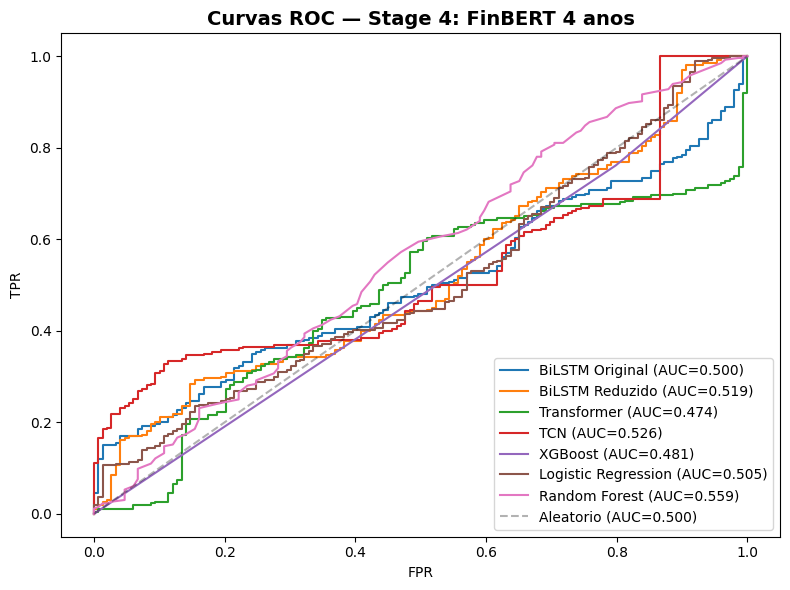

In [5]:
plot_roc_curves(results, title="Curvas ROC — Stage 4: FinBERT 4 anos",
                save_path="results/stage4_roc.png")

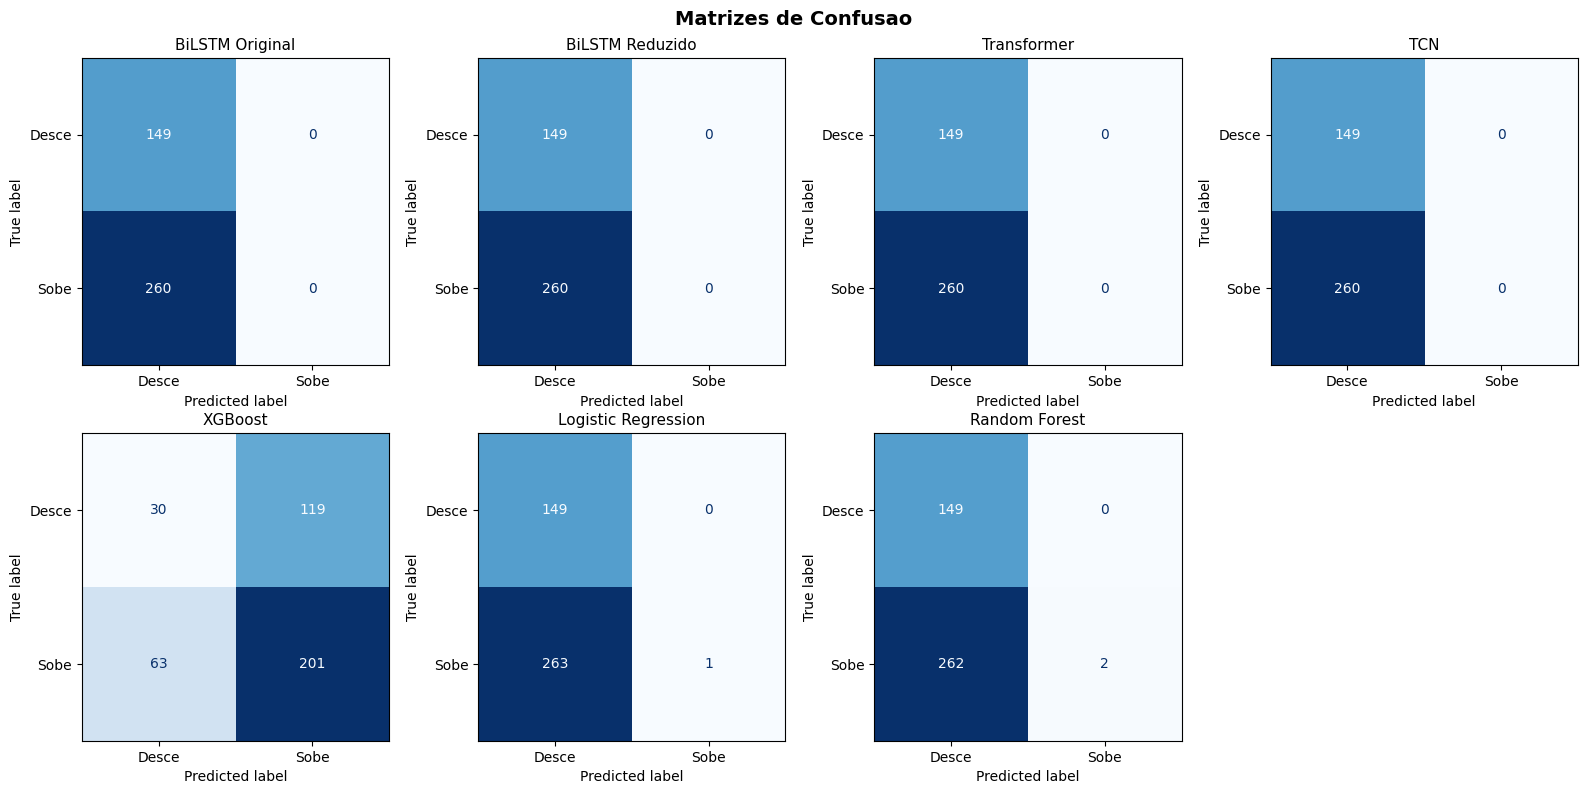

In [6]:
plot_confusion_matrices(
    {name: r["classification"] for name, r in results.items()},
    save_path="results/stage4_confusion.png",
)

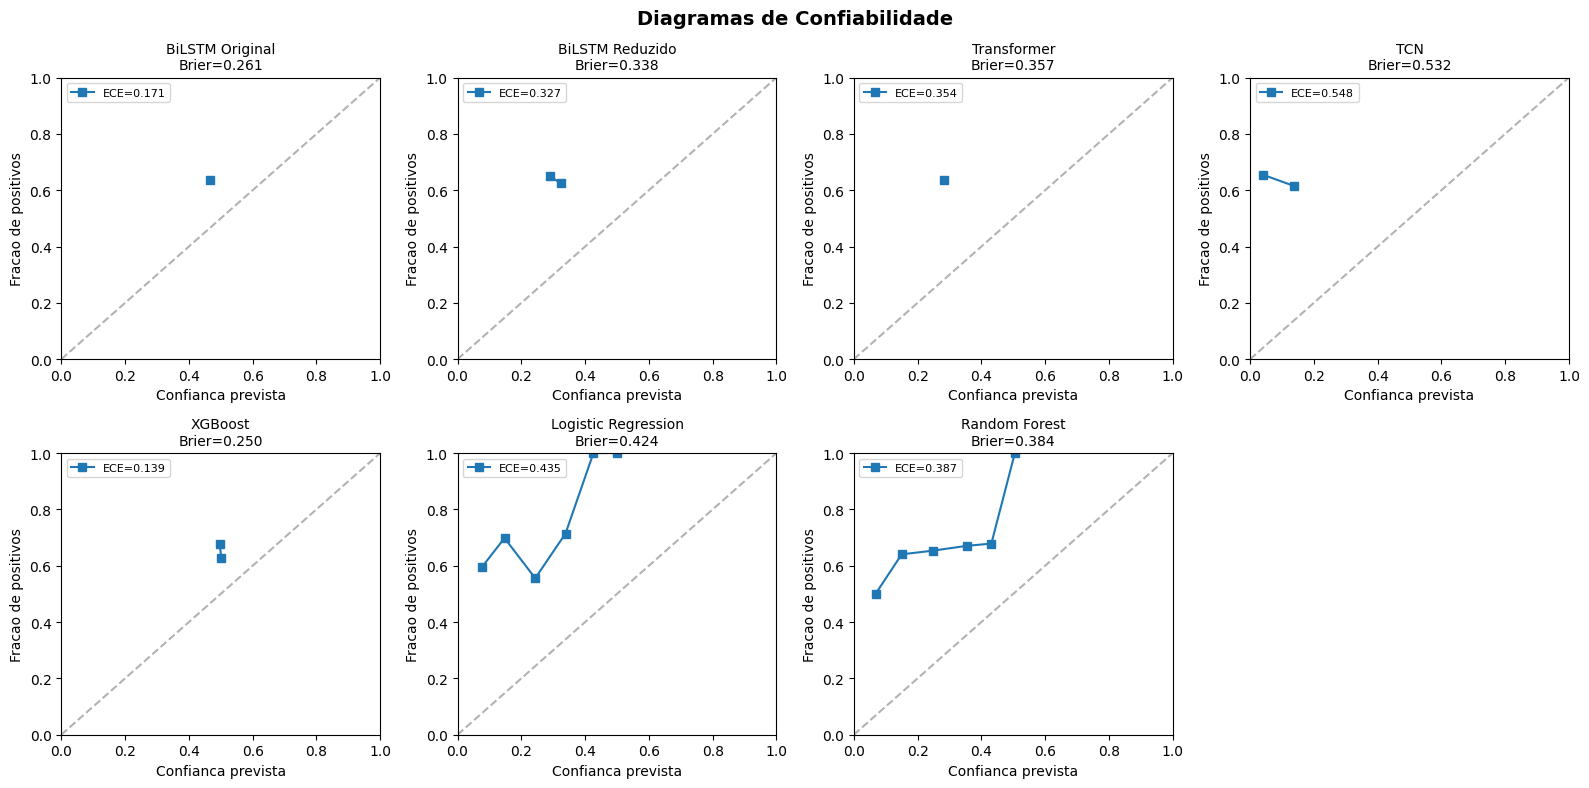

In [7]:
plot_calibration_diagrams(
    {name: r["calibration"] for name, r in results.items()},
    save_path="results/stage4_calibration.png",
)

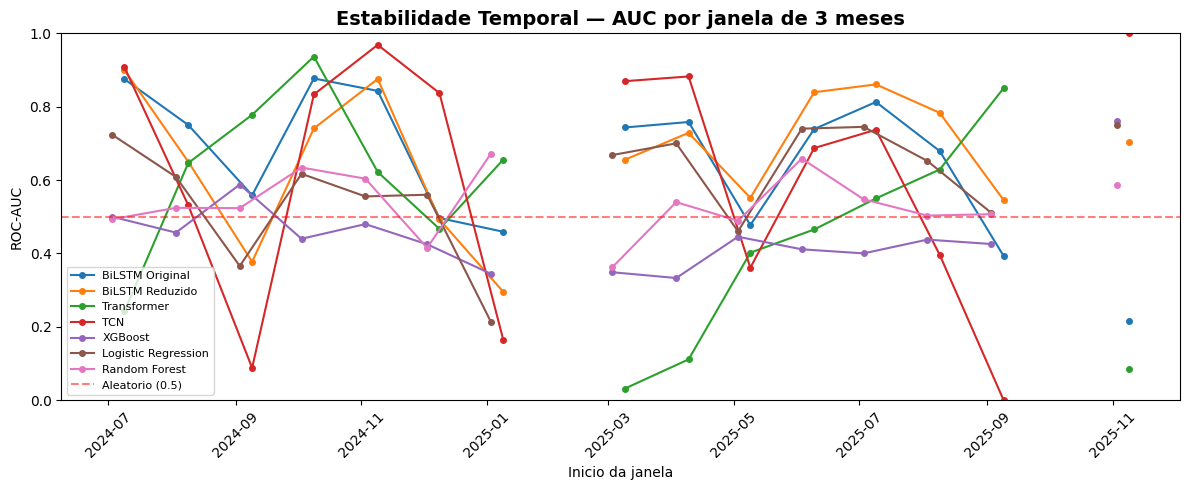

In [8]:
plot_temporal_stability(
    {name: r["temporal_stability"] for name, r in results.items()},
    save_path="results/stage4_temporal.png",
)

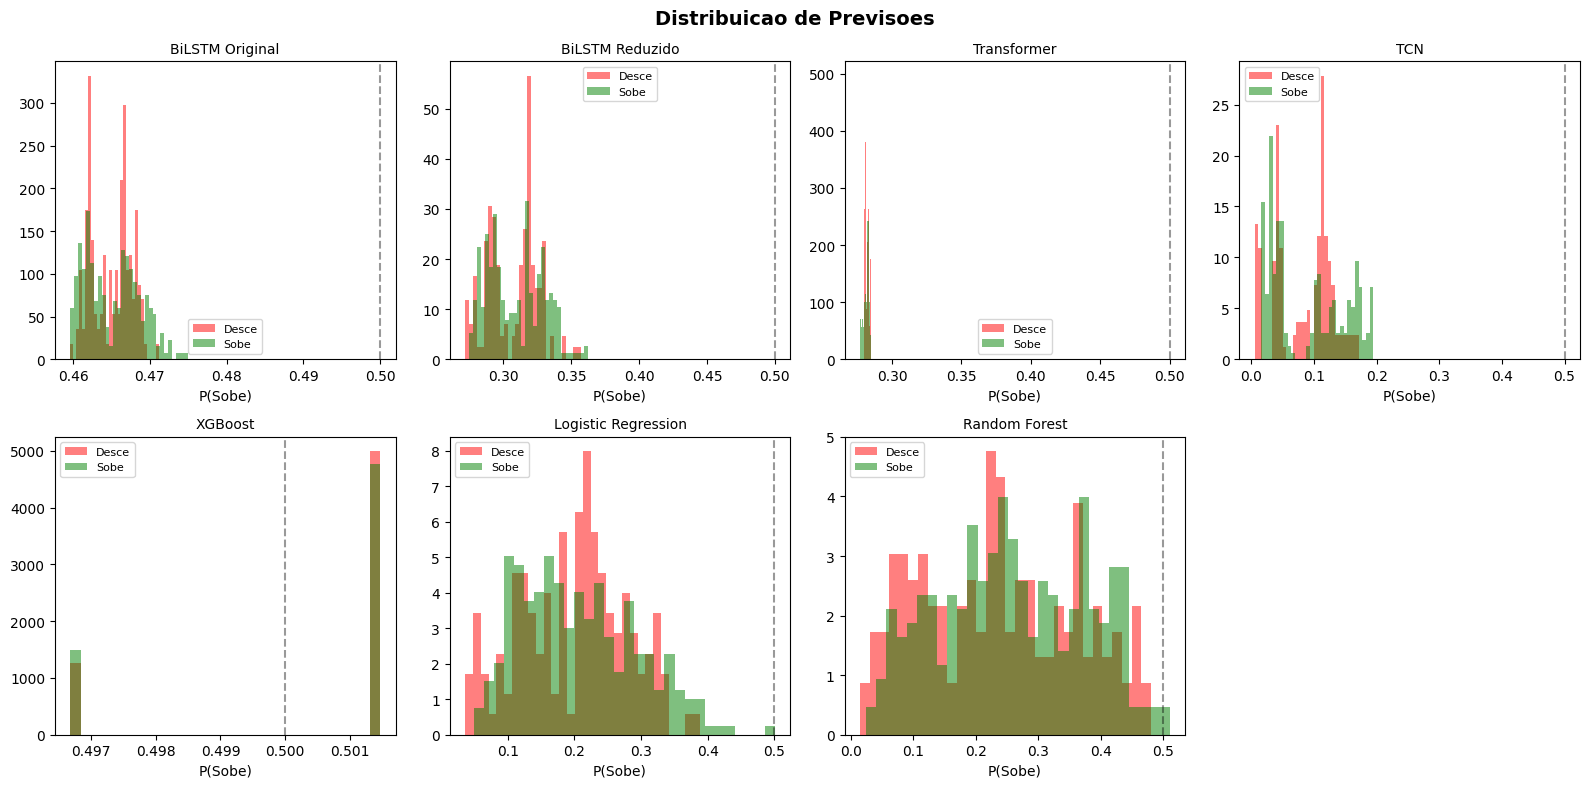

In [9]:
plot_prediction_distributions(
    {name: r["prediction_distribution"] for name, r in results.items()},
    save_path="results/stage4_distributions.png",
)

## Interpretabilidade (SHAP + Permutation Importance)

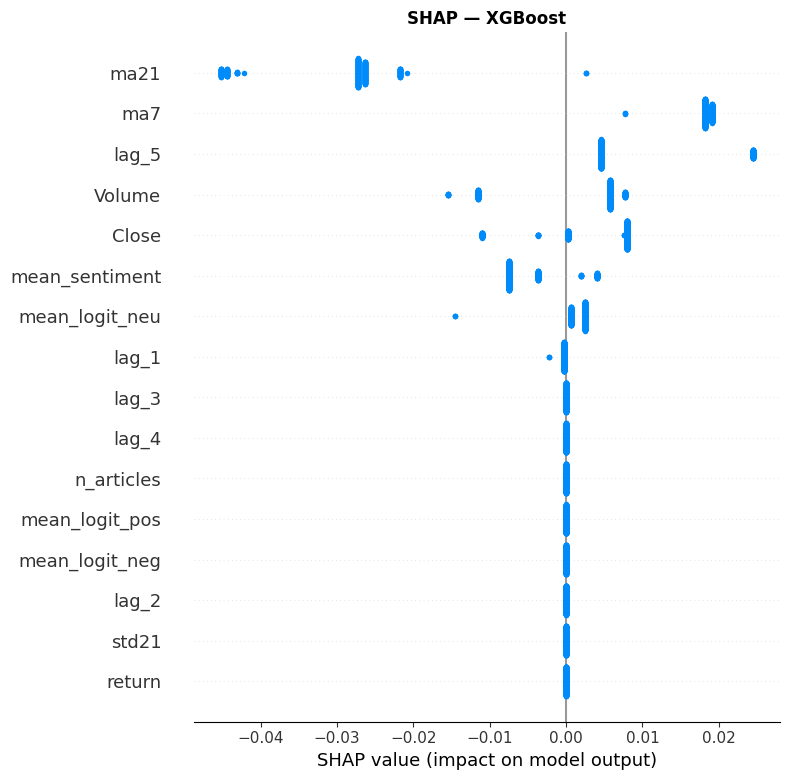

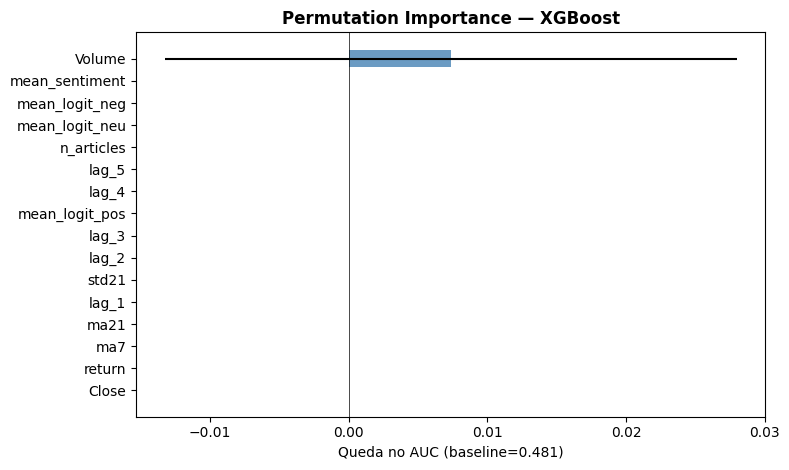

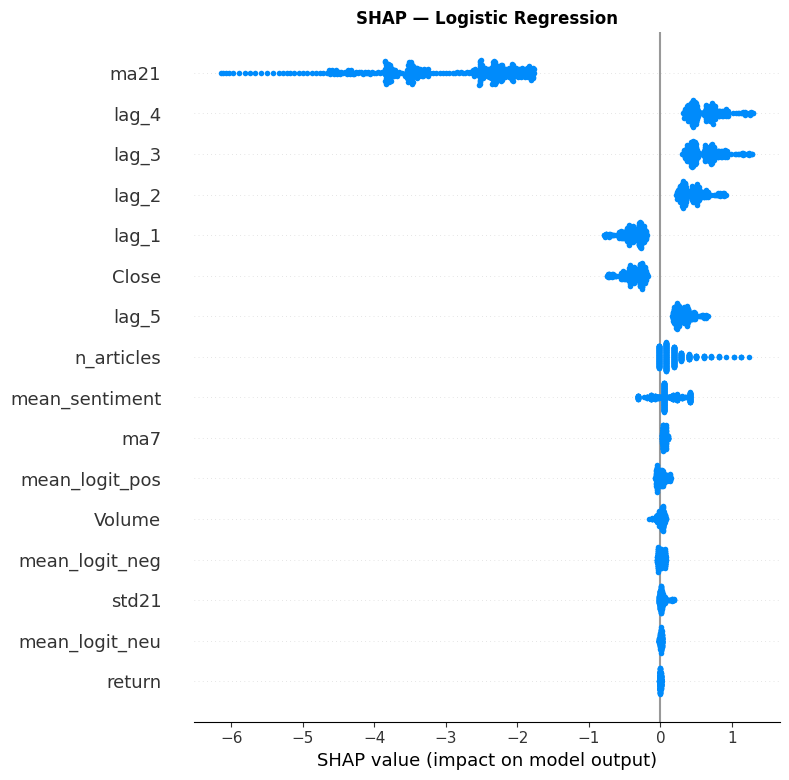

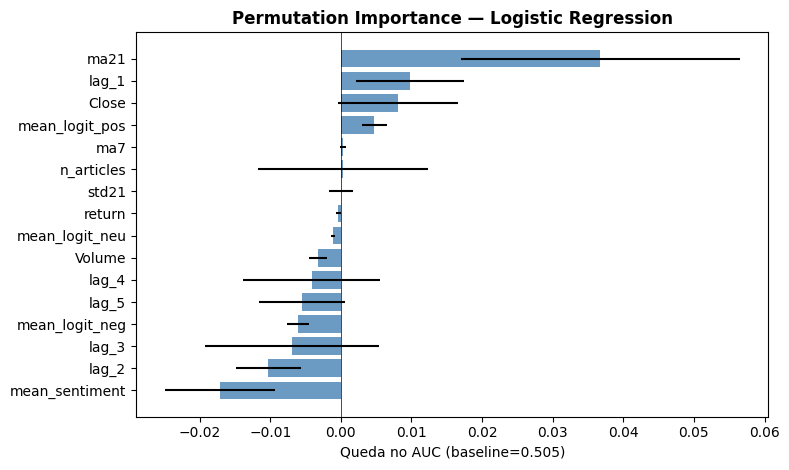

<Figure size 1000x480 with 0 Axes>

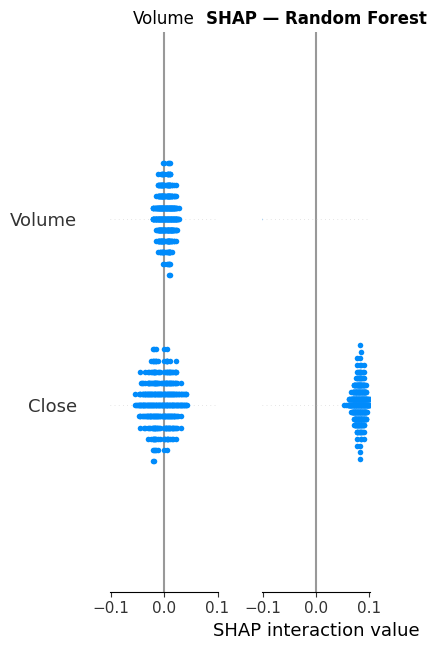

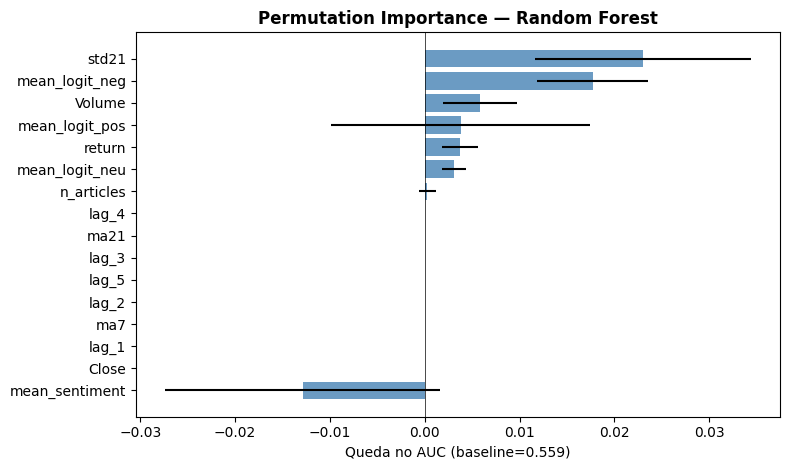

In [10]:
for name in ["XGBoost", "Logistic Regression", "Random Forest"]:
    r = results[name]
    if r["shap_values"] is not None:
        plot_shap_summary(
            r["shap_values"], data["feature_names"],
            title=f"SHAP — {name}",
            save_path=f"results/stage4_shap_{name.lower().replace(' ','_')}.png",
        )
    if r["permutation_importance"] is not None:
        plot_feature_importance(
            r["permutation_importance"],
            r["classification"]["roc_auc"],
            title=f"Permutation Importance — {name}",
            save_path=f"results/stage4_perm_{name.lower().replace(' ','_')}.png",
        )

## Curvas de aprendizado

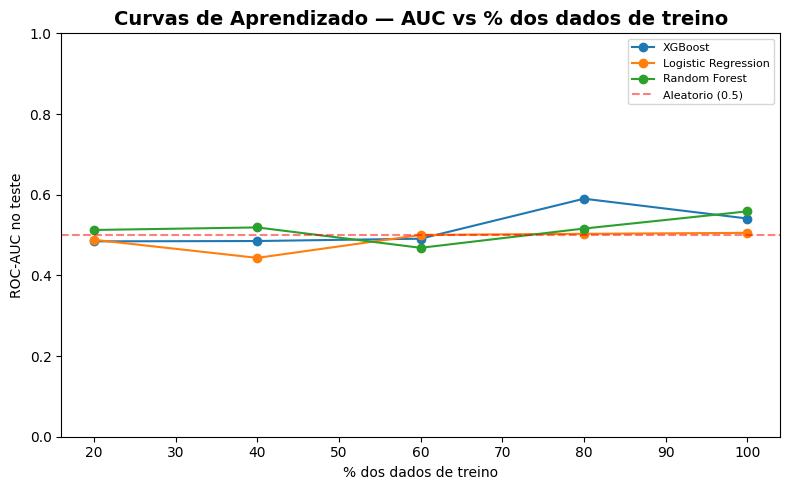

In [11]:
lc_results = {name: r["learning_curve"] for name, r in results.items()
               if r["learning_curve"] is not None}
if lc_results:
    plot_learning_curves(lc_results, save_path="results/stage4_learning_curves.png")

## Variacoes de hiperparametros

In [12]:
VARIATIONS = {
    "Transformer d=32": {"model_name": "transformer", "model_params": {"d_model": 32, "nhead": 2}},
    "Transformer d=128": {"model_name": "transformer", "model_params": {"d_model": 128, "nhead": 8}},
    "Transformer 4L": {"model_name": "transformer", "model_params": {"n_layers": 4}},
    "XGBoost depth=3": {"model_name": "xgboost", "model_params": {"max_depth": 3}},
    "XGBoost depth=6": {"model_name": "xgboost", "model_params": {"max_depth": 6}},
    "XGBoost 500 trees": {"model_name": "xgboost", "model_params": {"n_estimators": 500}},
    "BiLSTM drop=0.1": {"model_name": "bilstm_original", "model_params": {"dropout": 0.1}},
    "BiLSTM drop=0.5": {"model_name": "bilstm_original", "model_params": {"dropout": 0.5}},
    "BiLSTM h=256": {"model_name": "bilstm_original", "model_params": {"hidden_size": 256}},
    "TCN k=2": {"model_name": "tcn", "model_params": {"kernel_size": 2}},
    "TCN k=5": {"model_name": "tcn", "model_params": {"kernel_size": 5}},
    "TCN [32,32]": {"model_name": "tcn", "model_params": {"num_channels": [32, 32]}},
    "LR C=0.01": {"model_name": "logistic_regression", "model_params": {"C": 0.01}},
    "LR C=100": {"model_name": "logistic_regression", "model_params": {"C": 100}},
    "LR L1": {"model_name": "logistic_regression", "model_params": {"penalty": "l1", "solver": "saga"}},
    "RF depth=5": {"model_name": "random_forest", "model_params": {"max_depth": 5}},
    "RF depth=20": {"model_name": "random_forest", "model_params": {"max_depth": 20}},
    "RF 500 trees": {"model_name": "random_forest", "model_params": {"n_estimators": 500}},
}

var_results = {}
for display_name, config in VARIATIONS.items():
    print(f"\nVariacao: {display_name}")
    var_results[display_name] = train_and_evaluate(
        model_name=config["model_name"],
        data=data,
        model_params=config.get("model_params", {}),
        compute_shap=False,
        compute_learning_curve=False,
    )

18:54:51 [INFO] 
18:54:51 [INFO] Modelo: transformer
18:54:51 [INFO] Split — treino: 1901 | val: 407 | teste: 409
18:54:51 [INFO] ============================================================
18:54:51 [INFO] Class weights: sobe=0.856, desce=1.168 (balance: 53.9% sobe)



Variacao: Transformer d=32


18:54:51 [INFO] Epoch   1/50 | loss 0.6909 | val_loss 0.7097 | val_acc 36.9% | lr 1.00e-03
18:54:51 [INFO] Epoch   2/50 | loss 0.6780 | val_loss 0.7771 | val_acc 36.9% | lr 1.00e-03
18:54:52 [INFO] Epoch   3/50 | loss 0.6634 | val_loss 0.8555 | val_acc 36.9% | lr 1.00e-03
18:54:52 [INFO] Epoch   4/50 | loss 0.6467 | val_loss 0.9722 | val_acc 36.9% | lr 1.00e-03
18:54:52 [INFO] Epoch   5/50 | loss 0.6383 | val_loss 1.0234 | val_acc 36.9% | lr 1.00e-03
18:54:53 [INFO] Epoch   6/50 | loss 0.6339 | val_loss 1.1632 | val_acc 36.9% | lr 1.00e-03
18:54:53 [INFO] Epoch   7/50 | loss 0.6290 | val_loss 1.1988 | val_acc 36.9% | lr 5.00e-04
18:54:53 [INFO] Epoch   8/50 | loss 0.6314 | val_loss 1.1483 | val_acc 38.1% | lr 5.00e-04
18:54:54 [INFO] Epoch   9/50 | loss 0.6257 | val_loss 1.2119 | val_acc 36.9% | lr 5.00e-04
18:54:54 [INFO] Epoch  10/50 | loss 0.6135 | val_loss 1.2287 | val_acc 36.9% | lr 5.00e-04
18:54:54 [INFO] Epoch  11/50 | loss 0.6177 | val_loss 1.2101 | val_acc 36.9% | lr 5.00e-04


Variacao: Transformer d=128


18:54:55 [INFO] Epoch   1/50 | loss 0.7125 | val_loss 0.8041 | val_acc 36.9% | lr 1.00e-03
18:54:55 [INFO] Epoch   2/50 | loss 0.6779 | val_loss 0.9030 | val_acc 36.9% | lr 1.00e-03
18:54:56 [INFO] Epoch   3/50 | loss 0.6645 | val_loss 1.0312 | val_acc 36.9% | lr 1.00e-03
18:54:56 [INFO] Epoch   4/50 | loss 0.6614 | val_loss 0.8526 | val_acc 37.1% | lr 1.00e-03
18:54:57 [INFO] Epoch   5/50 | loss 0.6699 | val_loss 0.7895 | val_acc 53.3% | lr 1.00e-03
18:54:57 [INFO] Epoch   6/50 | loss 0.6859 | val_loss 0.9781 | val_acc 37.3% | lr 1.00e-03
18:54:57 [INFO] Epoch   7/50 | loss 0.6370 | val_loss 1.1257 | val_acc 37.6% | lr 1.00e-03
18:54:58 [INFO] Epoch   8/50 | loss 0.6270 | val_loss 1.2458 | val_acc 37.3% | lr 1.00e-03
18:54:58 [INFO] Epoch   9/50 | loss 0.6490 | val_loss 1.1981 | val_acc 37.6% | lr 1.00e-03
18:54:59 [INFO] Epoch  10/50 | loss 0.6434 | val_loss 1.0384 | val_acc 39.1% | lr 1.00e-03
18:54:59 [INFO] Epoch  11/50 | loss 0.6432 | val_loss 1.1049 | val_acc 37.3% | lr 5.00e-04

...

/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
1


Variacao: RF depth=20


18:55:48 [INFO] AUC: 0.5567 | Acc: 36.6% | F1: 0.0296 | ECE: 0.3701 | Brier: 0.3718
18:55:48 [INFO]               precision    recall  f1-score   support

       Desce       0.36      0.99      0.53       149
        Sobe       0.67      0.02      0.03       264

    accuracy                           0.37       413
   macro avg       0.51      0.50      0.28       413
weighted avg       0.56      0.37      0.21       413

18:55:53 [INFO] 
18:55:53 [INFO] Modelo: random_forest
18:55:53 [INFO] Split — treino: 1922 | val: 412 | teste: 413
18:55:53 [INFO] ============================================================



Variacao: RF 500 trees


18:55:54 [INFO] AUC: 0.5621 | Acc: 36.6% | F1: 0.0150 | ECE: 0.3872 | Brier: 0.3833
18:55:54 [INFO]               precision    recall  f1-score   support

       Desce       0.36      1.00      0.53       149
        Sobe       1.00      0.01      0.02       264

    accuracy                           0.37       413
   macro avg       0.68      0.50      0.27       413
weighted avg       0.77      0.37      0.20       413



In [13]:
var_rows = []
for name, r in var_results.items():
    var_rows.append({
        "Variacao": name,
        "ROC-AUC": f"{r['classification']['roc_auc']:.4f}",
        "Accuracy": f"{r['classification']['accuracy']:.1%}",
        "F1": f"{r['classification']['f1']:.4f}",
        "ECE": f"{r['calibration']['ece']:.4f}",
    })

df_var = pd.DataFrame(var_rows)
print("\n" + "="*60)
print("VARIACOES DE HIPERPARAMETROS")
print("="*60)
display(df_var)


VARIACOES DE HIPERPARAMETROS


,Variacao,ROC-AUC,Accuracy,F1,ECE
0,Transformer d=32,0.5273,36.4%,0.0000,0.2578
1,Transformer d=128,0.5377,37.4%,0.0303,0.4508
2,Transformer 4L,0.3808,36.4%,0.0000,0.3430
3,XGBoost depth=3,0.4814,36.1%,0.0000,0.1543
4,XGBoost depth=6,0.5387,47.2%,0.4140,0.1466
5,XGBoost 500 trees,0.4814,55.9%,0.6884,0.1388
6,BiLSTM drop=0.1,0.5217,36.4%,0.0000,0.2681
7,BiLSTM drop=0.5,0.5370,36.4%,0.0000,0.2424
8,BiLSTM h=256,0.5197,36.4%,0.0000,0.1730
9,TCN k=2,0.5489,36.4%,0.0000,0.3689


## Salvar resultados

In [14]:
all_results = {**results, **var_results}
save_results_json(all_results, "results/stage4_metrics.json")
print("Resultados salvos em results/stage4_metrics.json")

18:56:04 [INFO] Resultados salvos em results/stage4_metrics.json


Resultados salvos em results/stage4_metrics.json
